First 5 rows of the dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       setosa  
1        0       setosa  
2        0       setosa  
3        0       setosa  
4        0       setosa  


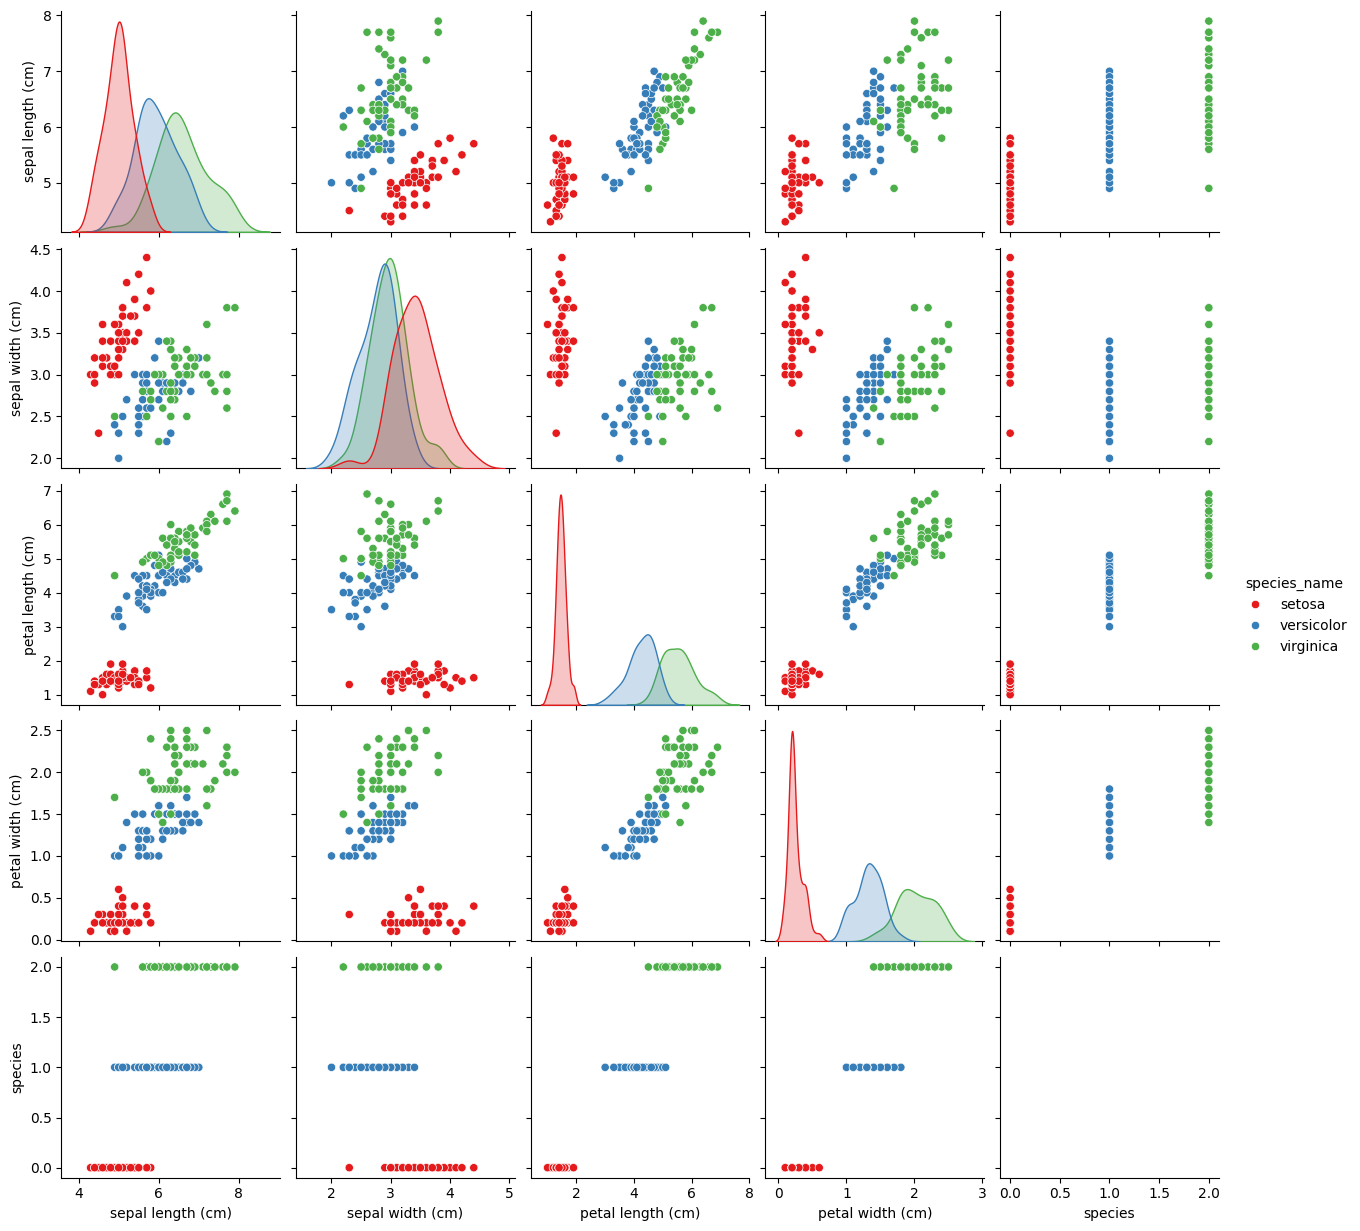

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# 1. Load the dataset
iris = load_iris()

# 2. Convert to a Pandas DataFrame for easier viewing
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target

# Map numerical targets to actual flower names for plotting
df['species_name'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

# 3. Print the first 5 rows
print("First 5 rows of the dataset:")
print(df.head())

# 4. Create a Pairplot to visualize relationships
sns.pairplot(df, hue='species_name', palette='Set1')
plt.show()

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Separate features (X) and target labels (y)
X = iris.data
y = iris.target

# 2. Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and train the model
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


Model Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



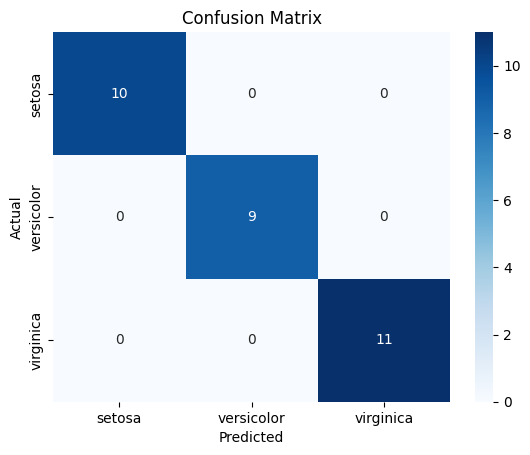

In [3]:
# 1. Make predictions on the test data
y_pred = model.predict(X_test)

# 2. Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

# 3. Print detailed classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# 4. Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [4]:
import pickle
from google.colab import files

# 1. Save the model to a file
with open('iris_model.pkl', 'wb') as file:
    pickle.dump(model, file)

print("Model saved as iris_model.pkl!")

# 2. Download the file to your computer
files.download('iris_model.pkl')

Model saved as iris_model.pkl!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>